  
last modified date : 2026.03  
제작 : 박광석 (모두의연구소)

# RAG 시작하기


# 들어가며  
최근 AI 서비스 현장에서 가장 빠르게 확산된 기술은 단연 **RAG(Retrieval-Augmented Generation)** 입니다. 2025년 10월 현재, RAG는 일부 기술 기업만의 선택이 아니라, 전 세계 조직들이 LLM을 실제 업무에 적용할 때 거의 기본적으로 도입하는 **표준 구조**가 되었습니다. 고객지원, 내부 문서 검색, 정책 질의응답, 기술 매뉴얼 분석처럼 근거 기반 답변이 필요한 대부분의 서비스가 RAG 중심으로 재편되는 흐름입니다.  
  
이렇게 RAG가 널리 쓰이는 이유는 명확합니다. 실제 환경에서 중요한 것은 모델의 크기가 아니라 **최신 정보에 기반한 정확한 답변**이기 때문입니다. 조직의 지식은 계속 바뀌고, 서비스는 출처가 명확해야 하며, 사용자마다 필요한 맥락도 다릅니다. RAG는 모델이 필요한 순간마다 적절한 정보를 검색해 활용하도록 설계되어, 비용·정확성·보안·업데이트 편의성까지 모두 충족합니다. 그래서 RAG는 오늘날 “LLM을 실전에서 제대로 쓰기 위한 기본 프레임워크”로 자리 잡고 있습니다.  

# 1. LLM 시장의 흐름  

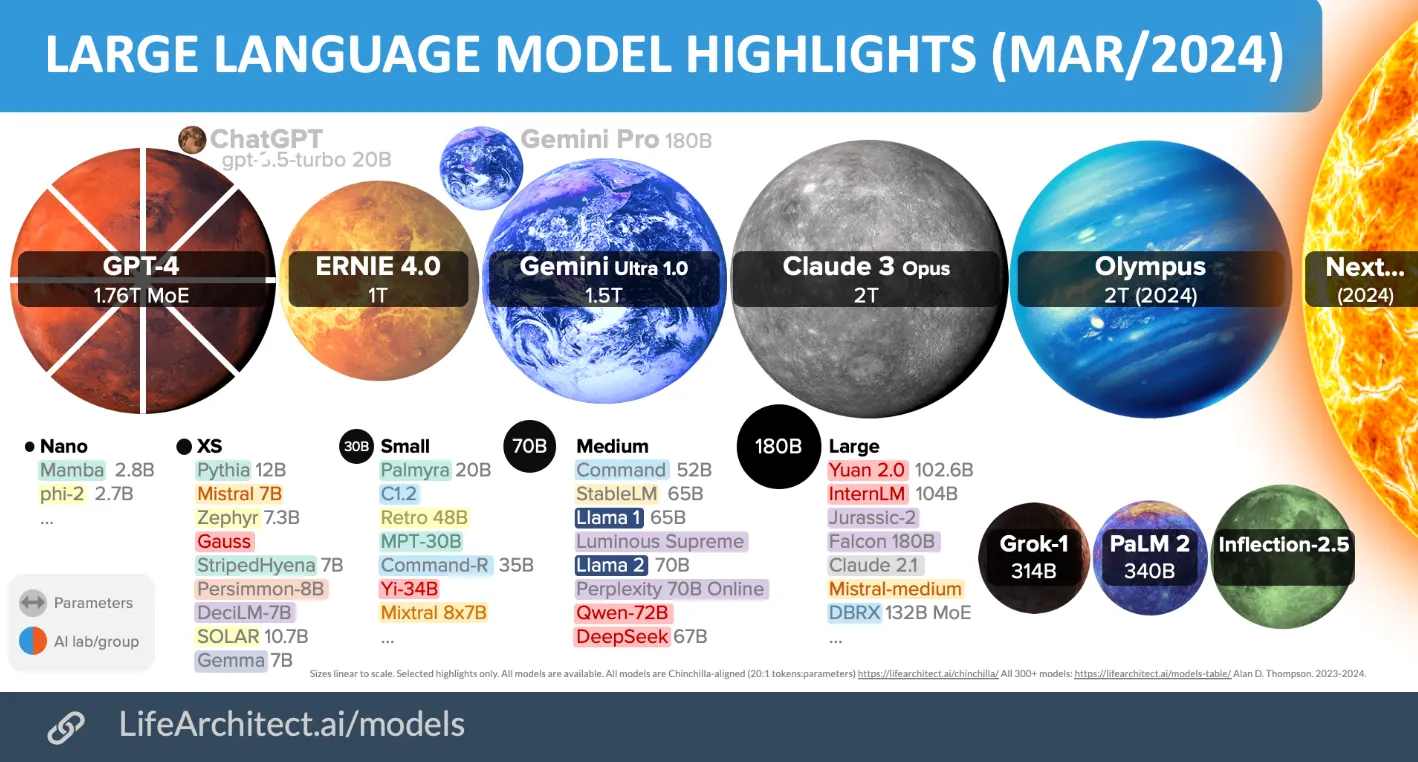

[출처 : https://www.grandviewresearch.com/industry-analysis/chatbot-market]

최근 몇 년간 LLM의 크기와 성능은 눈에 띄게 성장했습니다. 2023년 10월, 서비스로 등장한 ChatGPT의 모델 GPT3은 매개변수 1,750억개 (175B)를 사용했습니다. 2025년 10월, 현재 여러분들이 사용하시는 Claude OPUS는 6조개(6T) 의 매개변수를 사용하고 있습니다. 크기에 맞춰 성능 또한 눈부신 발전을 이루었으며, 현재 GPT, Gemini, Claude, Mistral 등 다양한 모델들이 등장하면서 인공지능이 단순한 챗봇을 넘어 생성형 도우미, 코딩 파트너, 리서치 조교로 삶에 깊숙히 스며들어있습니다.

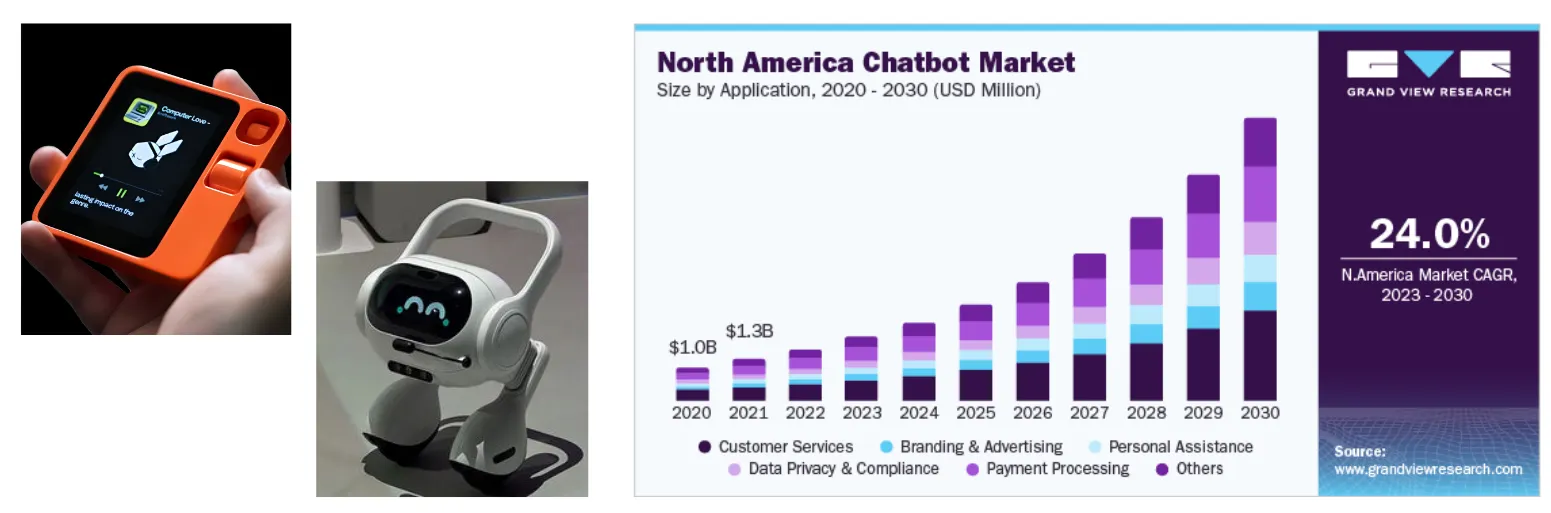

한편, AI를 서비스에 적용하기 위한 시장의 흐름은 On-device, 그리고 맞춤형 고객 챗봇으로 발전합니다. 24시간 일할 수 있으며, 빠르게 정보를 제공할 수 있기 때문입니다. 하지만 실제로, ‘특정 도메인’에서의 AI의 활용은 위에 언급했던 규모의 파라미터까지의 LLM을 필요로 하지 않으며, Physical AI에는 오히려 모델의 크기가 장애로 작용합니다.  결국 시장이 요구하는 것은 “더 큰 모델”이 아니라 “더 현명하게 활용하는 모델”입니다.

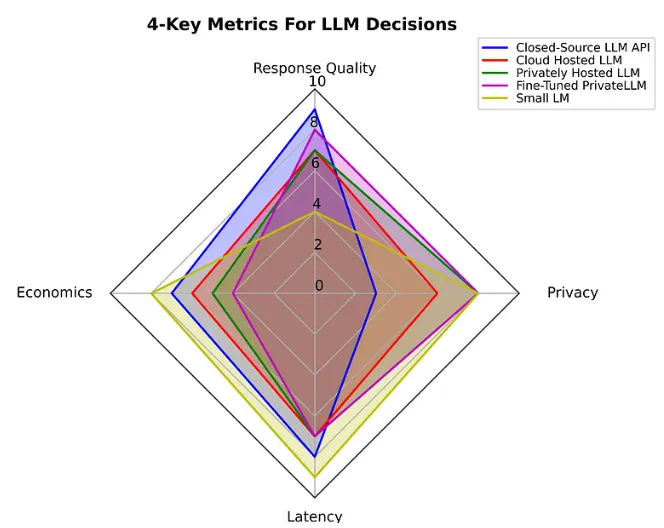

[출처 : https://towardsdatascience.com/4-crucial-factors-for-evaluating-large-language-models-in-industry-applications-f0ec8f6d4e9e]

기업들이 운영 비용을 고려하며, 공통적으로 찾는 가치는 다음 세 가지로 요약됩니다.  
1️⃣ 질적으로 우수한 응답(정확성)  
2️⃣ 빠른 반응 속도(효율성)  
3️⃣ 보안과 비용의 균형(실용성)  

# 2. Fine Tuning 의 한계

기업 맞춤형 챗봇을 개발하거나 특정 도메인 모델을 만들 때, 가장 먼저 떠오르는 접근법이 바로 Fine-tuning입니다. Fine-tuning은 이미 학습된 대형 모델 위에 새로운 데이터셋을 추가로 학습시켜, 특정 업무나 말투에 최적화시키는 방법입니다. 예를 들어 ‘법률 문서 요약용 LLM’, ‘고객센터 전용 챗봇’, ‘의료 영상 보고서 생성기’ 같은 것이죠.  
하지만 앞서 소개한 LLM을 Fine tuning한다고 생각한다면, 그리고 서비스에 적용하려면 고가의 GPU 서버가 필요하고, 실시간 응답을 유지하려면 안정적인 인프라와 대역폭도 요구됩니다. 기업 입장에서는 이것이 곧 ‘비용의 문제’로 직결됩니다. “좋은 답변을 얻기 위해 매달 수천만 원의 서버비를 감당할 수 있을까?”대부분의 기업이 고민하는 지점입니다.

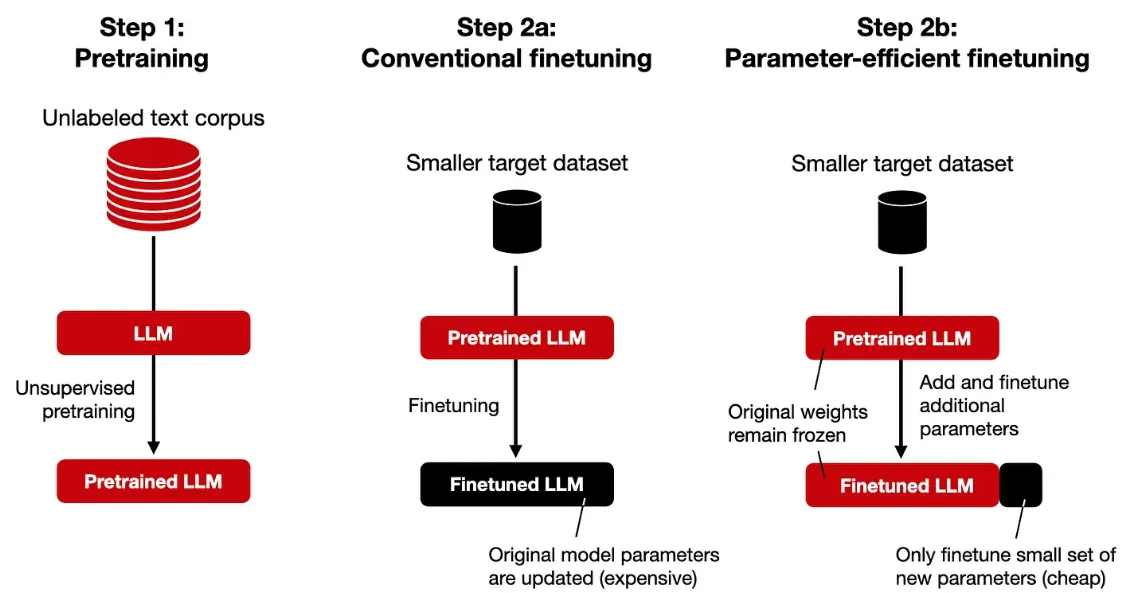

[출처 : https://magazine.sebastianraschka.com/p/finetuning-llms-with-adapters]

비용을 줄이는 획기적인 기법으로 소개된 Parameter Efficient Fine Tuning도 마찬가지입니다. Gradient 계산은 그대로 이루어지기 때문에, 훈련에 여전히 적지 않은 비용을 사용합니다.

Fine Tuning은 비용문제 말고도, 여러 한계점을 가지고 있습니다.

### Quiz  

병원에서 사용하는 챗봇을 상상해봅시다. 운영에 어떤 어려움이 있을 것 같나요?

Answer  
- 데이터 최신성 문제: 새로운 문서나 규정이 생길 때마다 다시 학습해야 하므로, 지속적인 업데이트가 비효율적입니다.
- 출처 불명: Fine-tuning된 모델이 어떤 근거로 답했는지 추적하기 어렵습니다.
- 개인화 한계: 동일한 모델이 모든 사용자에게 같은 방식으로 반응합니다.
- 보안: 개인에 맞춘 답을 학습하려면, 개인의 데이터를 학습해야 합니다. 모델은 학습한 데이터를 재현할 수 있습니다.
- 할루시네이션: 존재하지 않는 정보를 그럴듯하게 만들어내는 현상이 여전히 존재합니다.

즉, Fine-tuning은 모델 자체는 개선되지만, **지식 관리나 신뢰성 측면에서는 여전히 불완전**합니다.

특히 의료, 법률, 연구 분야처럼 “출처가 명확해야 하는 도메인”에서는 치명적인 한계점을 가지고 있는 것입니다.

# 3. Retrieval Augment Generation

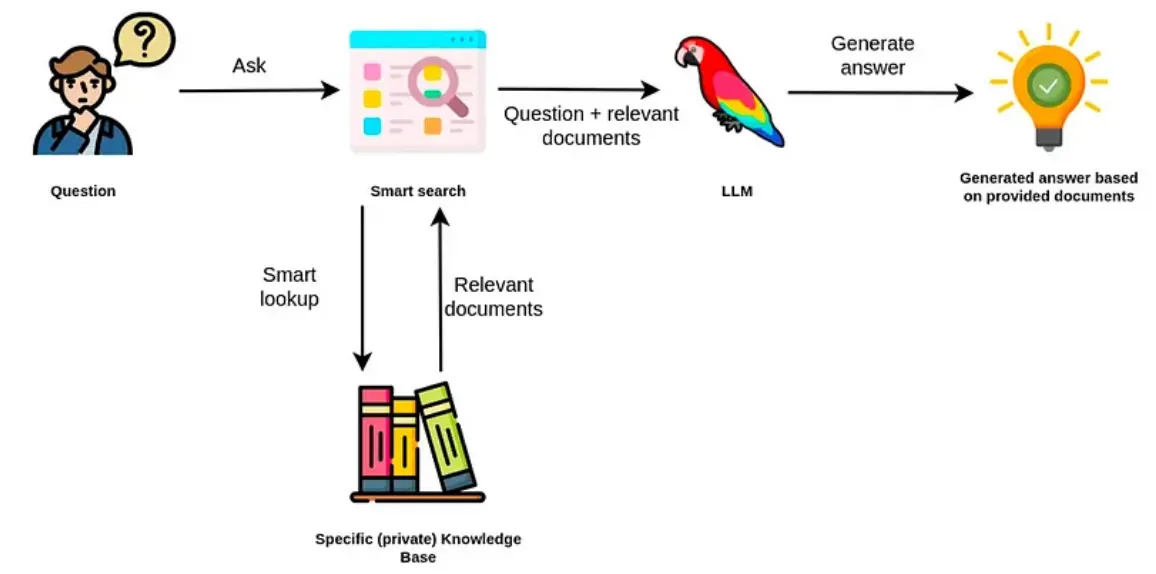

[출처 : https://neo4j.com/blog/what-is-rag/]

이런 흐름에서 등장한 새로운 접근이 바로 RAG(Retrieval-Augmented Generation) 입니다.
RAG는 “모든 걸 외워두는 모델”이 아니라, 필요한 순간마다 검색해서 답하는 모델을 만드는 방법입니다.
예를 들어, 모델이 법률 상담을 할 때 매번 최신 법령 데이터베이스를 참조한다면, 굳이 그 모든 데이터를 다시 학습시킬 필요가 없겠죠?

Fine-tuning 과 비교하자면, Fine tuning은 “기억을 늘리는 방법”이고, RAG는 “기억보다 검색을 잘하게 만드는 방법”입니다. 이는 마치 학생이 백과사전을 전부 외우는 대신, 필요한 정보를 빠르게 찾아보는 능력을 기르는 것과 같습니다.

RAG는 말 그대로 Retrieval(검색) + Generation(생성)의 결합입니다.
모델이 답을 만들기 전에, 먼저 신뢰할 수 있는 데이터베이스나 문서에서 관련 내용을 검색하고,
그 결과를 참고하여 더 정확하고 근거 있는 답변을 생성합니다.

이 구조를 조금 더 구체적으로 살펴보면 다음과 같습니다:  
1️⃣ Query 이해: 사용자의 질문을 받아 의미를 파악하고 벡터로 변환합니다.  
2️⃣ Retrieval 단계: 미리 구축된 문서 임베딩(VectorStore)에서 관련 내용을 검색합니다.  
3️⃣ Generation 단계: 검색된 문서를 Prompt에 삽입하여 LLM이 답변을 생성합니다.  

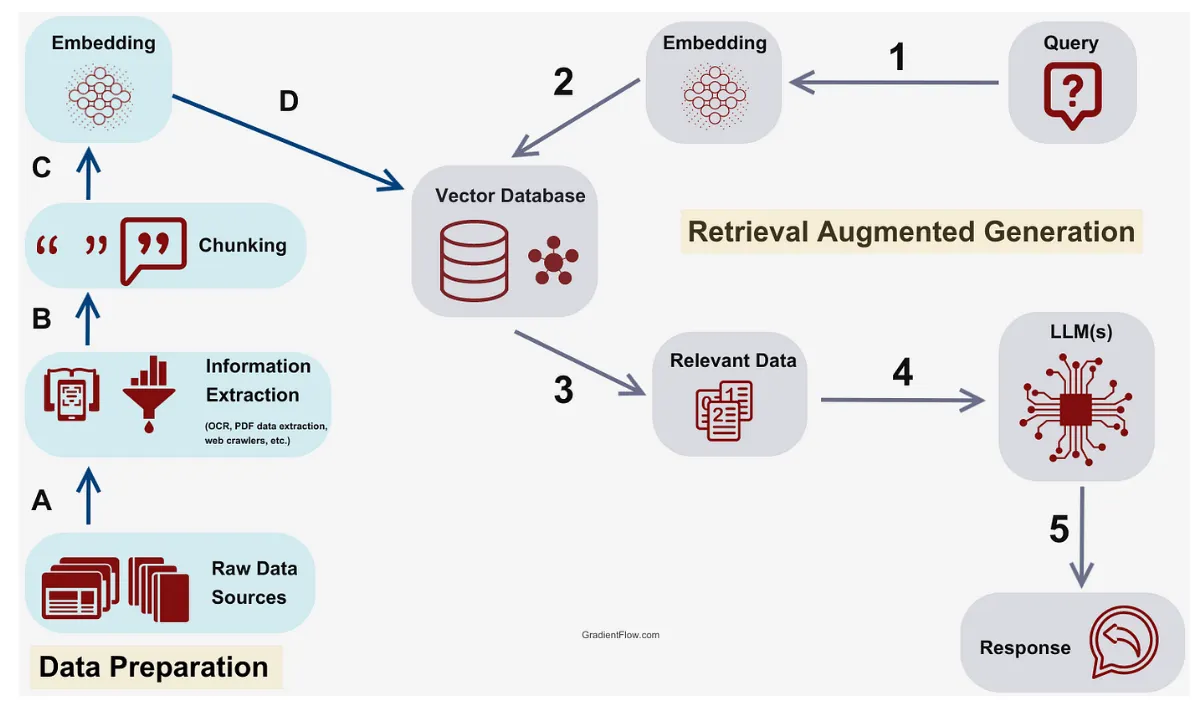

[출처 : https://gradientflow.com/techniques-challenges-and-future-of-augmented-language-models/]

위의 다이어그램은 RAG의 전형적인 데이터 흐름 구조를 단계별로 구분한 것입니다.

왼쪽의 **A~D** 는 ‘데이터 준비(Data Preparation)’ 과정, 오른쪽의 **1~5** 는 ‘검색 및 생성(Retrieval & Generation)’ 과정에 해당합니다.

### **데이터 준비(Data Preparation)**

🔹 A. Raw Data Sources

가장 먼저, RAG 시스템의 기반이 되는 원시 데이터(Raw Data) 를 준비합니다.
이 단계에서는 문서, 논문, 웹페이지, 내부 매뉴얼, PDF 보고서 등
검색 가능한 모든 자료를 수집하게 됩니다.
이 데이터가 이후 LLM이 참고할 지식 저장소의 원천이 됩니다.

예: 회사 매뉴얼, 고객 FAQ, 기술 블로그, 연구 논문 등

🔹 B. Information Extraction

다음으로는 수집된 데이터에서 실제로 사용할 유의미한 텍스트 정보를 추출합니다.
OCR(이미지 → 텍스트 변환), 웹 크롤링, API 호출 등을 통해
비정형 데이터를 정형화하고, 불필요한 요소(광고, HTML 태그 등)는 제거합니다.
이 과정을 거치면 “검색 가능한 텍스트 단위”로 정제된 데이터셋이 완성됩니다.

예: PDF의 본문만 추출하거나, 기사에서 헤더·푸터 제거

🔹 C. Chunking

이제 정제된 문서를 작은 단위(Chunk) 로 분할합니다.
LLM은 한 번에 처리할 수 있는 토큰 수가 제한되어 있기 때문에,
긴 문서를 그대로 저장하면 검색 효율이 떨어집니다.
그래서 문단, 문장, 혹은 일정 길이(예: 500 tokens) 단위로 나누는 것이 일반적입니다.
이렇게 나눈 조각들이 나중에 문맥 단위 검색의 기본이 됩니다.

예: 기술 매뉴얼을 챕터별로, FAQ를 문항별로 나누기

🔹 D. Embedding

이제 각 텍스트 조각(Chunk)을 벡터 형태로 변환(Embedding) 합니다.
Embedding 모델은 문장의 의미를 수치 벡터(예: 768차원)로 표현하여
유사한 의미의 문장은 벡터 공간상에서도 가깝게 배치되도록 합니다.
이 벡터들이 Vector Database 에 저장되어, 이후 검색 시 빠르게 매칭됩니다.

예: “환불 정책”과 “반품 기준”은 Embedding 공간에서 가깝게 위치

### **검색 및 생성(Retrieval & Generation)**

🔸 1. Query (질의 입력)

사용자가 질문을 입력하면, 시스템은 이 텍스트를
먼저 같은 Embedding 모델을 이용해 벡터 형태로 변환합니다.
이렇게 하면 질문도 문서와 동일한 공간에서 비교할 수 있습니다.

예: “우리 회사의 환불 규정은?” → 벡터로 변환

🔸 2. Embedding → Vector Database 검색

변환된 쿼리 벡터를 Vector Database 와 비교하여
가장 유사한 문서 조각(Chunk)을 찾아냅니다.
이때 검색 방법으로는 cosine similarity, FAISS, Pinecone, Chroma 등이 자주 사용됩니다.

예: 쿼리 벡터와 가장 유사한 상위 3개의 문단을 검색

🔸 3. Relevant Data

검색 결과로 얻은 문서 조각들이 바로 Relevant Data 입니다.
즉, 사용자의 질문과 의미적으로 가까운 실제 데이터 조각들이죠.
이 데이터들은 그대로 LLM에 전달되어, 답변 생성 시 ‘참고 문맥’ 역할을 합니다.

🔸 4. LLM(s) — 답변 생성

이제 LLM이 Retrieval 단계에서 가져온 데이터(문맥)을 입력받아
자연스러운 형태의 답변을 생성합니다.
이 과정은 단순 생성이 아니라, “검색된 정보에 근거한 생성”입니다.
즉, 모델이 스스로 지식을 만들어내는 대신, 실제 근거에 기반해 응답하게 됩니다.

예: “우리 회사의 환불 규정은 주문 후 7일 이내입니다.” (문서 근거 기반 답변)

🔸 5. Response

마지막으로 LLM이 생성한 답변이 사용자에게 전달됩니다.
이때 일부 시스템은 출처 링크나 참고 문서 ID를 함께 표시하여
“이 답변이 어떤 근거에서 나왔는가”를 투명하게 보여줍니다.

예: “출처: 고객정책매뉴얼.pdf, p.42”

# 4. RAG의 장점

### Quiz

[다음 웹사이트](http://www.chatpdf.com)에서 아래 파일을 이용, 데미안의 생김새를 확인해봅시다!

아래 링크에서 파일을 다운로드하여 사용하도록 합니다.  
- [Demian.pdf](https://www.holybooks.com/wp-content/uploads/Demian-By-Hermann-Hesse.pdf)

Answer: 질의를 했을 때, 답변을 생성하고, 출처를 표시할 수 있는 것을 확인할 수 있었습니다.  

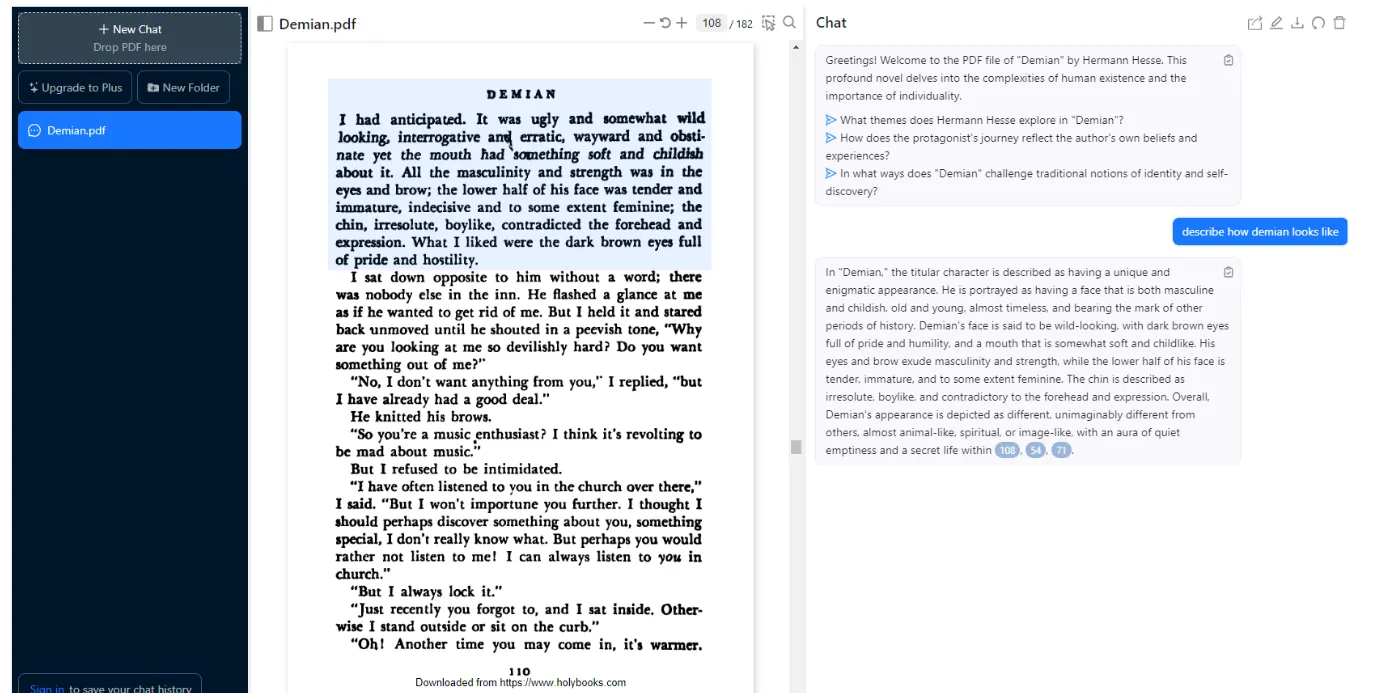

RAG의 핵심 장점은 **모델을 다시 학습시키지 않아도 지식을 갱신할 수 있다는 점**입니다.

새로운 데이터가 생기면, 단순히 벡터 데이터베이스(VectorStore)를 업데이트하면 됩니다.

이는 곧 **비용 절감**, **개발 속도 향상**, **실시간 업데이트**로 이어집니다.

또한, 검색 기반이기 때문에 **답변의 출처를 명확하게 제시**할 수 있습니다.

사용자는 “이 문장이 어디에서 나온 건가요?”라는 질문에 즉시 근거를 확인할 수 있죠.

이는 연구, 보고, 법률, 의료, 정책 분야 등에서 **신뢰성 확보에 결정적인 장점**입니다.

RAG의 대표적 활용 예시는 다음과 같습니다.

- **Open-domain QA:** “서울의 인구는?” 같은 일반 질의응답
- **Fact Verification:** 뉴스나 논문 속 주장의 진위 검증
- **Abstractive QA:** 여러 문서를 요약해 완전한 문장으로 답변
- **Question Generation:** 정답을 기반으로 새로운 질문을 생성
- **기업용 챗봇:** 내부 문서 기반 질의응답 (예: 사내 정책, 제품 매뉴얼)
- **연구 및 XAI:** 모델이 생성한 근거를 직접 인용하여 설명
  
요약하자면, RAG는 “모델이 더 이상 모든 것을 기억할 필요가 없게 하는 기술입니다.

이제 AI는 ‘모든 것을 아는 존재’가 아니라, 필요할 때 정확히 찾아서 말하는 존재로 진화하고 있습니다.

2021년 후반에 처음 등장한 RAG, 2025년 현재까지도 많은 연구자들이 이러한 장점에 반해 RAG를 사용하고 있으며, 국내외 관공서/기업들이 앞다투어 도입하고 있습니다.

#5. Langchain

RAG의 큰 성공을 견인하는 또 하나의 요인은 Langchain입니다. LangChain은 LLM을 활용한 애플리케이션 개발을 손쉽게 만드는 프레임워크입니다.
기존에는 LLM을 직접 제어하기 위해 Prompt 설계, API 호출, 결과 파싱, Memory 관리 등 복잡한 코드를 작성해야 했습니다. LangChain은 이런 과정을 모듈 단위로 나누어, “조립식 파이프라인” 형태로 구현할 수 있게 해줍니다.

예를 들어, 사용자가 PDF를 업로드하고 질문을 입력하면
→ LangChain이 문서를 로드하고
→ Text Splitter가 문단 단위로 분할하고
→ Embedding 모델이 벡터로 변환해 VectorStore에 저장하고
→ Retriever가 질문과 가장 유사한 문서를 찾아
→ LLM이 최종 답변을 생성하는 구조를 자동으로 연결해줍니다.

Python과 JavaScript를 모두 지원하며, Prompt, Chain, Agent, Memory 등 핵심 구성요소를 직접 정의할 수도 있습니다. 즉, “LLM 애플리케이션의 백엔드 로직을 시각적으로 설계하듯 구성할 수 있는 툴”이라고 이해하시면 됩니다.

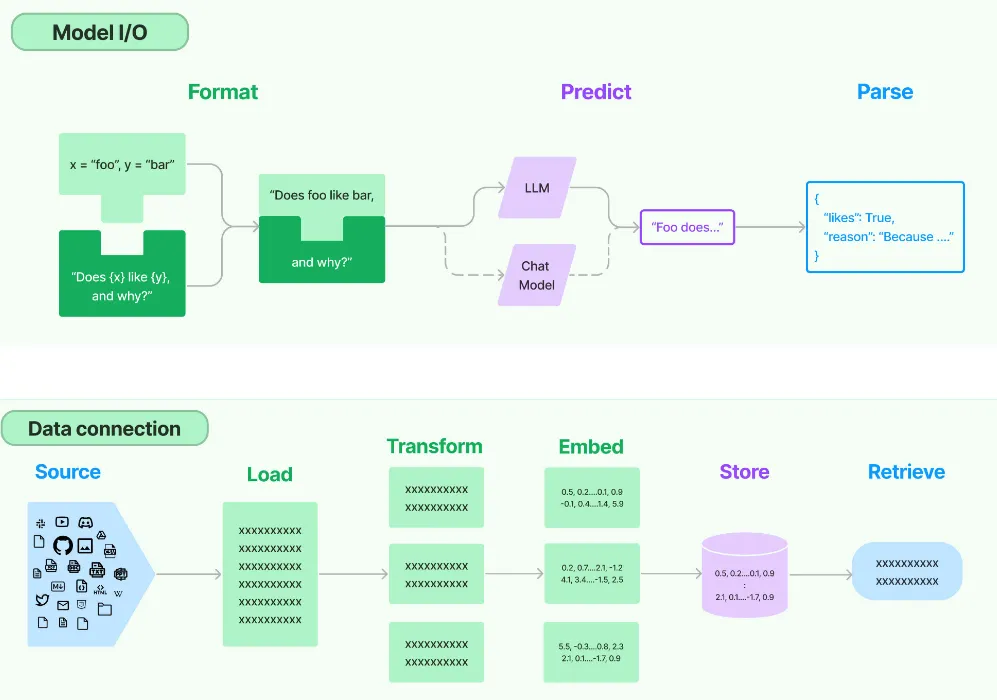

[랭체인의 Plug & Play Pipeline, [출처 : Langchain]]

LangChain의 장점은 단순히 편리하다는 것을 넘어, 다양한 LLM을 쉽게 교체할 수 있다는 점입니다.
예를 들어 OpenAI GPT에서 Gemini로 바꾸려면 단 한 줄의 코드만 수정하면 됩니다.
또한 메모리 관리, API 요청 최적화, 체인 실행 로그 등 개발자 친화적 기능도 풍부합니다.

요약하자면, LangChain은 “RAG를 구현하는 데 가장 직관적이고 강력한 프레임워크”입니다.

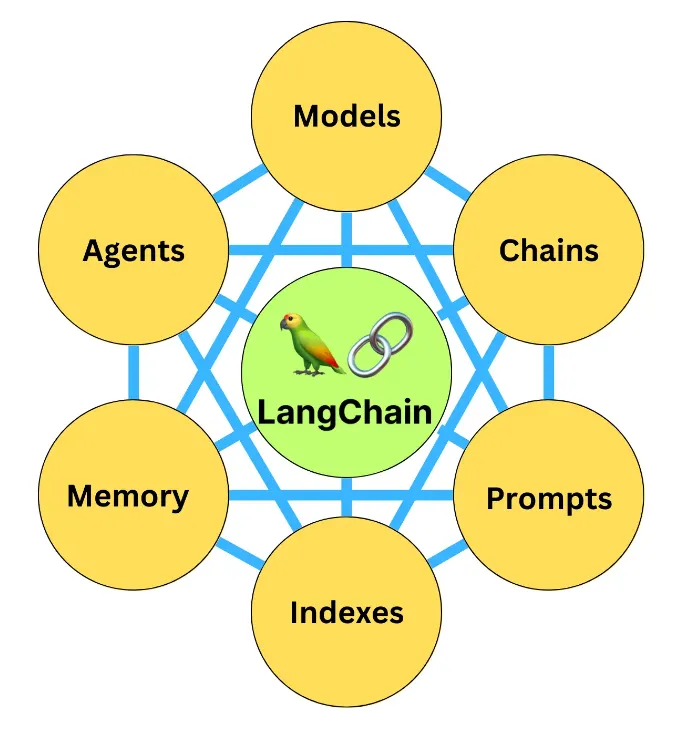

[출처 : Langchain]

LangChain은 위 다이어그램처럼 여섯 개의 주요 구성요소(Models, Chains, Prompts, Indexes, Memory, Agents)가 유기적으로 연결되어 있습니다.

### 🔹 1. Models — “두뇌 역할”

LangChain의 중심에는 LLM이 있습니다.
Models는 GPT, Gemini, Claude, Mistral 등 언어모델 자체를 제어하는 부분이에요.
이 모듈은 사용자의 질의를 받아 “문장을 이해하고, 답변을 생성하는 두뇌” 역할을 합니다.
LangChain은 다양한 모델을 지원하므로, 코드 한 줄로 모델을 교체할 수 있다는 장점이 있습니다.

예: OpenAI, Gemini, Anthropic, Cohere, HuggingFaceHub 등

즉, Models는 LLM의 중심 엔진이며, 모든 Chain과 Agent가 이 엔진을 호출해 응답을 만듭니다.

### 🔹 2. Prompts — “명령어 설계자”

Prompt는 모델에게 무엇을, 어떻게 말할지를 지시하는 명령 템플릿입니다.
LangChain에서는 Prompt를 단순 문자열이 아닌 객체 형태로 관리할 수 있습니다.
즉, “질문 틀(template)”을 미리 만들어 두고,
사용자가 입력한 내용을 여기에 삽입하는 방식으로 동작합니다.

예: “당신은 친절한 AI 어시스턴트입니다. 사용자의 질문에 명확하고 간결하게 답해주세요: {question}”

이렇게 구성하면 매번 Prompt를 새로 작성할 필요 없이,
일관된 문체와 응답 형식을 유지할 수 있습니다.

### 🔹 3. Chains — “논리의 흐름 연결자”

Chains는 여러 단계를 가진 LLM 호출을 하나의 파이프라인으로 연결하는 모듈입니다.
예를 들어,
1️⃣ 질문을 이해하고,  
2️⃣ 관련 문서를 검색하고,  
3️⃣ 결과를 요약해 답변을 만드는 과정이 있다면 —  
이 전체를 Chain으로 묶을 수 있습니다.

LangChain은 SimpleChain, SequentialChain, LLMChain 등 다양한 형태를 제공하며,
각 단계 간 입력·출력을 자동으로 연결해줍니다.

즉, “Prompt → Model → Output Parser” 흐름을 자동으로 이어주는 역할이에요.

### 🔹 4. Indexes — “지식 탐색가”

Indexes는 문서, 데이터베이스, 또는 외부 지식 소스를
모델이 쉽게 탐색할 수 있도록 구조화하는 모듈입니다.
RAG에서 말하는 벡터 저장소(Vector Store),
즉 Embedding 기반 문서 검색이 바로 이 Index 모듈을 통해 이루어집니다.

예: FAISS, Chroma, Pinecone, Weaviate 등

이 모듈은 LangChain과 RAG가 결합될 때 핵심 역할을 합니다.
문서를 Embedding으로 변환해 저장하고,
사용자의 쿼리와 유사한 벡터를 검색해 모델에 전달하는 과정을 담당합니다.

### 🔹 5. Memory — “대화의 기억력”

Memory는 LangChain이 이전 대화 내용을 기억하고 맥락을 유지하도록 하는 모듈입니다.
일반적인 LLM API는 한 번의 요청에만 응답하지만,
Memory를 사용하면 “이전 질문에서 무슨 말을 했는가”를 참조할 수 있습니다.

예:

- 사용자: “어제 말했던 RAG 구조 다시 설명해줘.”
- 모델: “어제는 Retrieval과 Generation 단계를 중심으로 설명드렸습니다.”

이처럼 Memory는 대화형 AI에 필수적인 요소이며,
대화 맥락을 저장하고, 다음 Prompt에 자동으로 포함되도록 도와줍니다.

### 🔹 6. Agents — “행동하는 지능”

Agents는 LangChain의 가장 강력한 요소 중 하나입니다.
기존 LLM은 주어진 Prompt 내에서만 답변을 생성하지만,
Agent는 필요할 때 외부 도구를 직접 호출할 수 있습니다.

예를 들어 Agent는 다음과 같은 일을 스스로 수행할 수 있습니다:

- Google 검색 후 결과 요약
- SQL 데이터베이스 질의
- Python 코드 실행
- 파일 읽기/쓰기

즉, “모델이 직접 행동할 수 있는 시스템”을 만드는 핵심 컴포넌트입니다.
LangChain은 Tool, Planner, Executor 구조로 Agent를 구성하여,
모델이 스스로 판단해 적절한 도구를 사용하는 반 자율형 AI를 구현합니다.

# 6. Langchain 실습

Langchain 설치 및 OpenAI API 키를 등록하도록 합니다.  

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
!pip install -U -q langchain langchain-openai
!pip install -U -q langchain-community langchain-core
!pip install -U langchain-text-splitters


In [25]:
from google.colab import userdata
openai_api_key = userdata.get('OPENAI_API_KEY')

In [26]:
import os


### Step 1 : LLM 사용해보기  
Langchain의 대부분의 컴포넌트는 선언 - 호출의 간단한 방식으로 사용할 수 있도록 구성되었습니다.

ChatGoogleGenerativeAI 클래스로 Google의 Gemini 모델과 연결합니다. model 매개변수는 사용할 모델 버전을 지정하고, temperature는 응답의 창의성을 조절합니다(0에 가까우면 일관적, 1에 가까우면 창의적). max_output_tokens는 생성할 최대 토큰 수를 제한합니다

In [28]:
from langchain_openai import ChatOpenAI

# OpenAI API를 사용하는 설정으로 변경
# 모델명은 필요에 따라 "gpt-4o", "gpt-4-turbo", "gpt-3.5-turbo" 등으로 바꿀 수 있습니다.
llm = ChatOpenAI(
    model="gpt-4o",
    temperature=0.0,
    api_key=openai_api_key,
)

invoke() 메서드는 모델에 질문을 전달하고 완전한 응답을 한 번에 받는 가장 기본적인 방법입니다. 이 외에도 여러 질문을 한 번에 처리하는 generate()나, 긴 응답을 실시간으로 받는 stream() 메서드도 있습니다.

In [29]:
request = llm.invoke("파이썬에 대해 설명해줘")
print(request)


content='파이썬(Python)은 고급 프로그래밍 언어로, 1991년 귀도 반 로섬(Guido van Rossum)에 의해 처음 개발되었습니다. 파이썬은 그 간결하고 읽기 쉬운 문법 덕분에 초보자와 전문가 모두에게 인기가 많습니다. 다음은 파이썬의 주요 특징들입니다:\n\n1. **간결하고 명확한 문법**: 파이썬은 코드의 가독성을 높이기 위해 설계되었습니다. 이는 유지보수와 협업을 용이하게 합니다.\n\n2. **다양한 라이브러리와 프레임워크**: 파이썬은 데이터 분석, 웹 개발, 인공지능, 과학 계산 등 다양한 분야에서 사용할 수 있는 풍부한 라이브러리와 프레임워크를 제공합니다. 예를 들어, 데이터 분석에는 Pandas와 NumPy, 웹 개발에는 Django와 Flask, 인공지능에는 TensorFlow와 PyTorch 등이 있습니다.\n\n3. **플랫폼 독립성**: 파이썬은 다양한 운영 체제에서 실행될 수 있습니다. 이는 개발자가 특정 플랫폼에 구애받지 않고 코드를 작성할 수 있게 합니다.\n\n4. **인터프리터 언어**: 파이썬은 인터프리터 언어로, 코드를 한 줄씩 실행합니다. 이는 디버깅과 테스트를 용이하게 하지만, 컴파일 언어에 비해 실행 속도가 느릴 수 있습니다.\n\n5. **커뮤니티와 지원**: 파이썬은 방대한 사용자 커뮤니티를 가지고 있어, 다양한 문제 해결을 위한 자료와 지원을 쉽게 찾을 수 있습니다.\n\n파이썬은 그 유연성과 강력함 덕분에 웹 개발, 데이터 과학, 인공지능, 자동화 스크립트 작성 등 다양한 분야에서 널리 사용되고 있습니다.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 403, 'prompt_tokens': 16, 'total_tokens': 419, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0,

Query의 결과에는 답변 뿐만이 아닌, 메타데이터와 실행id가 함께 리턴됩니다.  
답변을 나타내는 content 키만 출력하도록 해보겠습니다.  

In [30]:
print(request.content)

파이썬(Python)은 고급 프로그래밍 언어로, 1991년 귀도 반 로섬(Guido van Rossum)에 의해 처음 개발되었습니다. 파이썬은 그 간결하고 읽기 쉬운 문법 덕분에 초보자와 전문가 모두에게 인기가 많습니다. 다음은 파이썬의 주요 특징들입니다:

1. **간결하고 명확한 문법**: 파이썬은 코드의 가독성을 높이기 위해 설계되었습니다. 이는 유지보수와 협업을 용이하게 합니다.

2. **다양한 라이브러리와 프레임워크**: 파이썬은 데이터 분석, 웹 개발, 인공지능, 과학 계산 등 다양한 분야에서 사용할 수 있는 풍부한 라이브러리와 프레임워크를 제공합니다. 예를 들어, 데이터 분석에는 Pandas와 NumPy, 웹 개발에는 Django와 Flask, 인공지능에는 TensorFlow와 PyTorch 등이 있습니다.

3. **플랫폼 독립성**: 파이썬은 다양한 운영 체제에서 실행될 수 있습니다. 이는 개발자가 특정 플랫폼에 구애받지 않고 코드를 작성할 수 있게 합니다.

4. **인터프리터 언어**: 파이썬은 인터프리터 언어로, 코드를 한 줄씩 실행합니다. 이는 디버깅과 테스트를 용이하게 하지만, 컴파일 언어에 비해 실행 속도가 느릴 수 있습니다.

5. **커뮤니티와 지원**: 파이썬은 방대한 사용자 커뮤니티를 가지고 있어, 다양한 문제 해결을 위한 자료와 지원을 쉽게 찾을 수 있습니다.

파이썬은 그 유연성과 강력함 덕분에 웹 개발, 데이터 과학, 인공지능, 자동화 스크립트 작성 등 다양한 분야에서 널리 사용되고 있습니다.


### Step2 : schema 사용해보기  

위에서는 일회성 대화만 다뤘지만, 실제로는 대화 맥락을 유지하거나 모델의 역할을 정의해야 하는 경우가 많습니다. Schema는 메시지를 구조화하고 역할별로 구분하여 복잡한 대화 흐름을 관리할 수 있게 해줍니다  
  
SystemMessage : LLM에 역할을 부여할 수 있습니다. 대화의 맥락을 부여하며, 행동 설정 혹은 제약을 위해 사용할 수 있습니다.  
HumanMessage : 사용자가 LLM에게 대화 혹은 요청을 위해 보내는 메세지입니다.  
AIMessage : AI assistent가 제공하는 메세지, 즉 대답입니다.  
이외에도 function call 로부터 주어진 message인 FunctionMessage가 있습니다.


In [32]:
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

In [34]:
os.environ['OPENAI_API_KEY'] = openai_api_key

In [36]:
messages = [
    SystemMessage(content="You are a helpful assistant that translates English to Korean."),
    HumanMessage(content="Translate this sentence: I love programming."),
]

# 현재 SystemMessages 가 지원되지 않아, convert_system_message_to_human=True 의 option을 llm 생성시에 사용해야 합니다
llm = ChatOpenAI(model="gpt-4o")
response = llm.invoke(messages)
print(response.content)

프로그래밍을 사랑합니다.


In [37]:
response

AIMessage(content='프로그래밍을 사랑합니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 30, 'total_tokens': 38, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_ad9444ef57', 'id': 'chatcmpl-DKFekOiQNwm54W8s3US2UmD3rIKKX', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cf9e5-d108-7d11-82df-0ef5d6b1e2e3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 30, 'output_tokens': 8, 'total_tokens': 38, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

AI의 답변은 AIMessage로 분류되어 있습니다.

### Step3 : Prompt Templete 사용해보기  
모델에 입력하는 prompt를 규격화하여 효율적으로 LLM을 사용할 수 있게 하는 모듈입니다.  
  
ex) "파란색 셔츠" 와 잘 어울리는 "바지"를 추천해줘!   
ex) "흰 티셔츠" 와 잘 어울리는  "모자"를 추천해줘!  
  
이렇게 예시의 반복되는 부분을 엔지니어링 할 수 있습니다.  

    
PromptTemplete : 일반적인 프롬프트 템플릿 생성 시 사용합니다.  
{ }로 묶인 부분을 변수로 활용합니다  


In [38]:
from langchain_core.prompts import PromptTemplate

prompt = PromptTemplate.from_template("{meat}를 맛있게 만드는 좋은 방법은?")
prompt.format(meat="닭고기")

'닭고기를 맛있게 만드는 좋은 방법은?'

ChatPromptTemplete : 채팅 LLM 특화, 위의 schema처럼 역할을 나누어 사용하도록 입력할 수 있습니다.  

In [39]:
from langchain_core.prompts import ChatPromptTemplate

templete = "당신은 최고의 번역가입니다 {input_language}를 {output_language}로 번역해서 알려주세요"
human_templete = "{text}"

chat_prompt = ChatPromptTemplate.from_messages([
    ("system", templete),
    ("human", human_templete),
])

format_message = chat_prompt.format_messages(input_language="English", output_language = "Korean", text = "I love pizza")

위의 Format한 prompt를 LLM에 넣어 결과를 확인할 수 있습니다.  

In [40]:
response = llm.invoke(format_message)
print(response.content)

저는 피자를 좋아해요.


### Step4 : Parser 사용해보기  

Parser는 llm에서 response로 넘어가는 text를 원하는 형태로 파싱하도록 도와주는 모듈입니다  

In [43]:
from langchain_core.output_parsers import BaseOutputParser

class CommaSeparatedListOutputParser(BaseOutputParser):
  #baseOutputParser를 상속받음
  #comma를 기준으로 문자열을 나누어주는 parser를 사용해보겠습니다
    def parse(self, text: str) -> list:
        return text.strip().split(", ")

CommaSeparatedListOutputParser().parse("hello , modulabs")

['hello ', 'modulabs']

### Step5 : Chain 사용하여 결합해보기  
Chain 은 Langchain의 핵심 기능으로, 위의 과정들을 묶어 한번에 수행할 수 있도록 합니다.  
다른 langchain의 구성끼리,  | 기호를 사용하여 연결할 수 있습니다.

In [44]:
templete = """당신은 쉼표로 구분된 목록을 생성하는 유용한 조수입니다. \
사용자가 카테고리를 전달하면 해당 카테고리에 속하는 5개의 객체를 쉼표로 구분된 목록으로 생성합니다. \
오직 쉼표로 구분된 목록만 반환하고 그 이상은 반환하지 마세요."""

human_templete = "{text}"

chat_prompt = ChatPromptTemplate.from_messages([
    ("system", templete),
    ("human", human_templete),
])

위에 정의한 프롬프트 탬플릿, LLM, Parser를 결합해보겠습니다.

In [45]:
chain = chat_prompt | llm | CommaSeparatedListOutputParser()
response = chain.invoke ("text : 색깔")
print(response)

['빨간색,파란색,노란색,초록색,보라색']


# 7. RAG의 한계와 개선, 그 후

RAG는 획기적인 방법 중 하나였지만, 여전히 여러 한계가 존재합니다.

- 검색 정확도 저하 (Retrieval Precision Problem)
    - 유사도 기반 검색이 문장 의미를 완벽히 포착하지 못해, 실제로는 중요한 문단이 누락되거나 덜 관련된 결과가 상위에 노출되는 경우가 있습니다.
    (예: 질문이 “환불 절차”인데, “결제 정책” 문단이 더 높은 점수를 받는 상황)
- 맥락 혼선 (Context Dilution)
    - 여러 개의 문단이 한꺼번에 전달되면, LLM이 핵심 문맥을 구분하지 못하고 답변의 초점이 흐려지거나 비논리적인 요약이 생성됩니다.
        
        (예: 서로 다른 시점의 정책 내용을 함께 참조해 모순된 답을 내놓는 경우)
        
- 할루시네이션
    - 모델이 검색된 문서에 존재하지 않는 정보를 그럴듯하게 만들어내는 현상입니다.
    이는 “문서에 없는 내용을 상상해 보충하는” 생성형 LLM의 본질적 특성에서 비롯됩니다.
    (예: 문서에 ‘환불 가능’만 언급돼 있는데 “14일 내 환불 가능”이라고 구체화해버리는 경우)

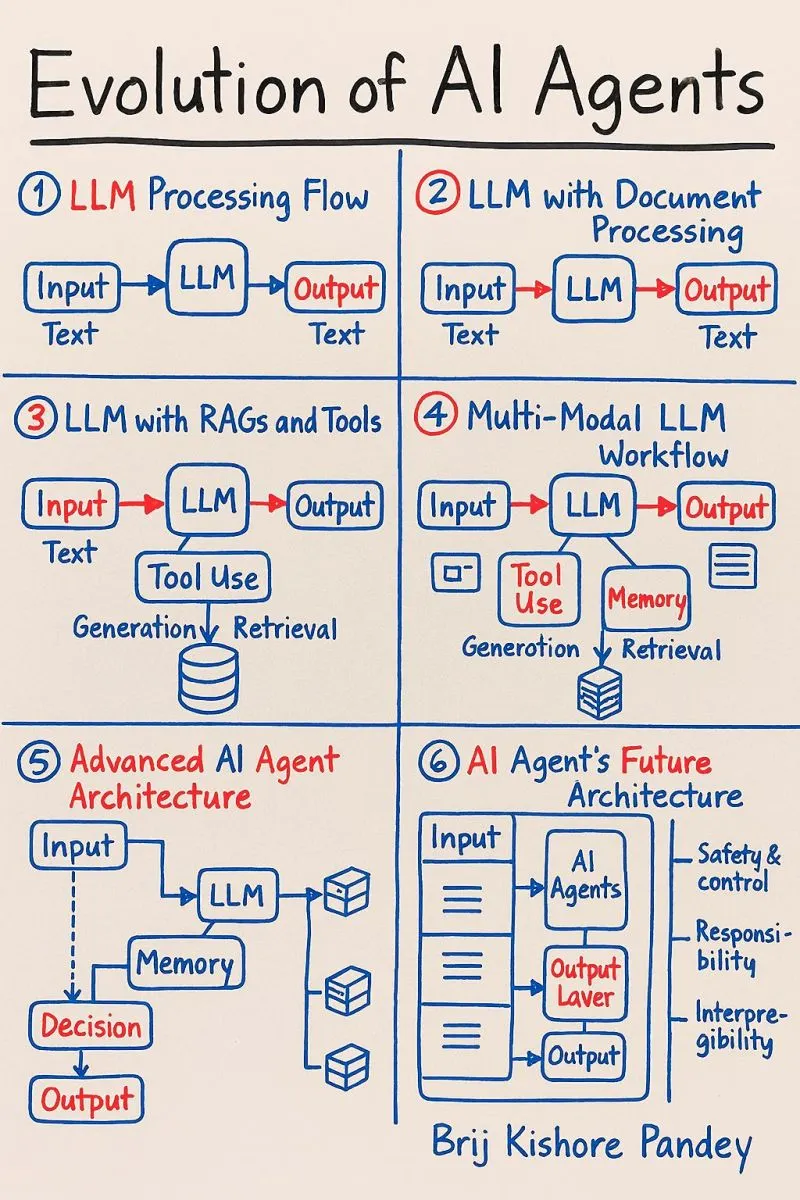

[출처 : https://www.linkedin.com/in/brijpandeyji]

이를 해결하기 위해, 연구자들은 Advanced RAG, Modular RAG 등 여러 기법을 제안하였고, 그 과정에서 인터넷 검색 같은 외부 리소스에 접근하는 등 언어모델 질의 외의 다른 작업을 수행하기 위해 ‘툴’ 과 ‘메모리’ 를 작업 프로세스에 결합하게 됩니다. 이는 LLM을 탑재한 AI Agent 페러다임으로 이어지게 됩니다.